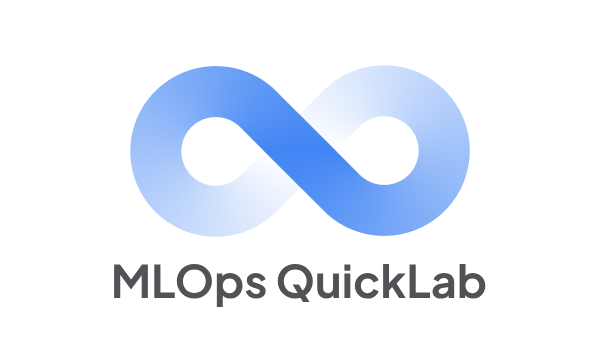

4. Vertex AI 소개 및 개요

In [1]:
!pip install datasets torchserve torch-model-archiver torch-workflow-archiver nvgpu

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.5 MB/s eta 0:00:00
  Created wheel for nvgpu: filename=nvgpu-0.10.0-py3-none-any.whl size=9544 sha256=dc7360ad3b3aac1909e3f35e38db85ca6e96dae26bdf954007d40a9237c0a60b
  Stored in directory: /root/.cache/pip/wheels/6e/4a/5d/db9b77ea9d1981efbe7a03a10318930d6c5897c85f751d52dc
Successfully built nvgpu


In [5]:
!pip install -U datasets huggingface_hub transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 80.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.19.0
    Uninstalling huggingface_hub-1.19.0:
      Successfully uninstalled huggingface_hub-1.19.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.0
    Uninstalling transformers-5.12.0:
      Successfully uninstalled transformers-5.12.0


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import seaborn as sns

from torch.utils.data import DataLoader
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import confusion_matrix
from datasets import load_dataset
from tqdm import tqdm
from typing import TypedDict
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
dataset = load_dataset("fancyzhx/ag_news")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
optimizer = AdamW(model.parameters(), lr=5e-5)
criterion = torch.nn.CrossEntropyLoss()

class DatasetItem(TypedDict):
    text: str
    label: str


def preprocess_data(dataset_item: DatasetItem) -> dict[str, torch.Tensor]:
    return tokenizer(dataset_item["text"], truncation=True, padding="max_length", return_tensors="pt")


train_dataset = dataset["train"].select(range(1200)).map(preprocess_data, batched=True)
test_dataset = dataset["test"].select(range(800)).map(preprocess_data, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 3
losses: list[float] = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}, Average Loss: {average_loss}")

Epoch 1: 100%|██████████| 150/150 [01:48<00:00,  1.38it/s]


Epoch 1, Average Loss: 0.6240837183594704


Epoch 2: 100%|██████████| 150/150 [01:56<00:00,  1.29it/s]


Epoch 2, Average Loss: 0.27690367005765437


Epoch 3: 100%|██████████| 150/150 [01:55<00:00,  1.30it/s]

Epoch 3, Average Loss: 0.1895617910909156


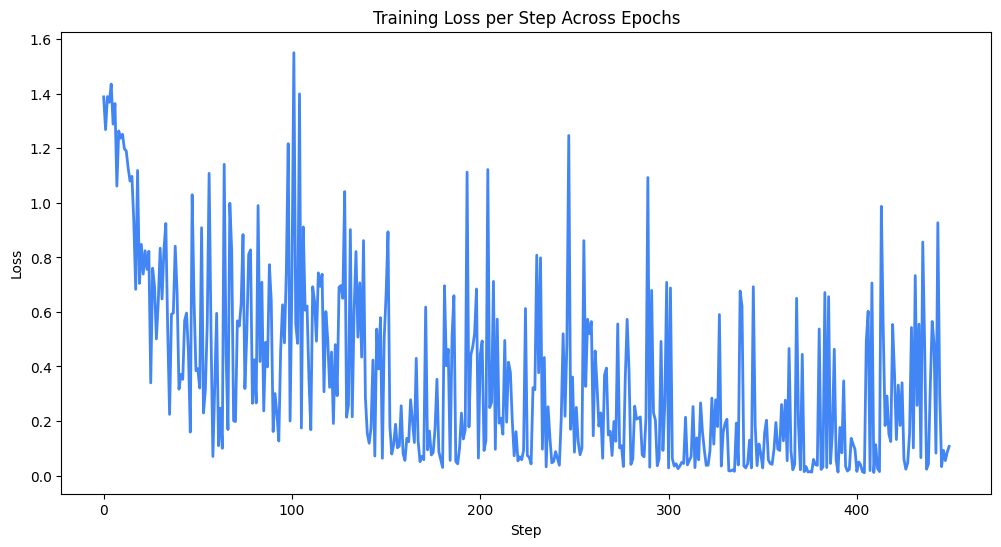

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(losses, color="#4285f4", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss per Step Across Epochs")
plt.show()

In [6]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)
        correct += (predicted_labels == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Evaluating: 100%|██████████| 100/100 [00:24<00:00,  4.10it/s]


Test Accuracy: 86.50%


In [7]:
test_input = "[Official] 'Legendary Coach Resigns → Appoints New Commander' Suwon Completes Coaching Staff... Scout Bae Ki-jong Joins + Coach Shin Hwa-yong Remains"
test_input_processed = tokenizer(test_input, truncation=True, padding="max_length", return_tensors="pt").to(device)
logits = model(**test_input_processed).logits
print(logits)
predicted_labels = torch.argmax(logits, dim=1)

labeling_mapper = ["world", "sports", "business", "sci/tech"]
print(labeling_mapper[predicted_labels[0]])

tensor([[ 1.9355,  1.2436, -1.3117, -2.0024]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
world


In [8]:
all_predictions: list[int] = []
all_labels: list[int] = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)

        all_predictions.extend(predicted_labels.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Evaluating: 100%|██████████| 100/100 [00:24<00:00,  4.09it/s]


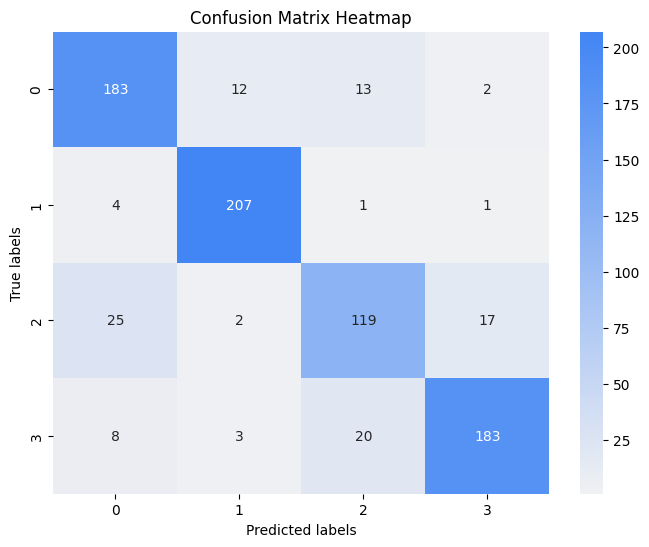

In [9]:
conf_matrix = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="g", cmap=sns.light_palette("#4285f4", as_cmap=True))
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

## TorchServe Archive

In [10]:
# 모델 체크포인트 저장.
model_save_path = "model.pth"
torch.save(model.state_dict(), model_save_path)

In [11]:
%%writefile handler.py
import json
import logging

import torch
from ts.context import Context
from ts.torch_handler.base_handler import BaseHandler
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification

logging.basicConfig(level=logging.INFO)

class ModelHandler(BaseHandler):
    def __init__(self):
        self.initialized = False
        self.tokenizer = None
        self.model = None

    def initialize(self, context: Context):
        properties = context.system_properties
        model_dir = properties.get("model_dir")
        self.initialized = True
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        self.model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
        model_path = model_dir + "/model.pth"
        self.model.load_state_dict(torch.load(model_path))
        self.model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
        self.model.eval()

    def preprocess(self, texts: list[str]) -> BatchEncoding:
        logging.info("preprocess", texts)

        inputs = self.tokenizer(texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        return inputs.to(device)

    def inference(self, input_batch: BatchEncoding) -> torch.Tensor:
        with torch.no_grad():
            outputs = self.model(**input_batch)
            logging.info("inference", outputs)
            return outputs.logits

    def postprocess(self, inference_output: torch.Tensor) -> list[dict[str, float]]:
        logging.info("postprocess", inference_output)

        probabilities = torch.nn.functional.softmax(inference_output, dim=1)
        return [{"label": int(torch.argmax(prob)), "probability": float(prob.max())} for prob in probabilities]

Writing handler.py


In [12]:
# bert vocab 파일 (아티팩트)

!wget https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt \
    -O bert-base-uncased-vocab.txt

--2026-06-28 13:21:24--  https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231508 (226K) [text/plain]
Saving to: ‘bert-base-uncased-vocab.txt’

bert-base-uncased-v 100%[===================>] 226.08K  --.-KB/s    in 0.02s   

2026-06-28 13:21:25 (12.1 MB/s) - ‘bert-base-uncased-vocab.txt’ saved [231508/231508]



In [13]:
# Torch serve archiver의 최종 파일 저장 위치.
# .mar 확장자 파일을 생성하여 패키징 하게 된다.

!mkdir -p model-store

## Register to Vertex AI

In [14]:
!torch-model-archiver \
    --model-name model \
    --version 1.0 \
    --serialized-file model.pth \
    --handler ./handler.py \
    --extra-files "bert-base-uncased-vocab.txt" \
    --export-path model-store \
    -f

In [15]:
# from google.colab import auth
# auth.authenticate_user()

In [16]:
from google.cloud import storage, aiplatform
from google.oauth2 import service_account

In [17]:
credentials = service_account.Credentials.from_service_account_file("credentials.json")

In [18]:
PROJECT_ID = "glassy-tower-499906-a1"                    # @param {type: "string"}
LOCATION = "asia-northeast3"                                       # @param {type: "string"}
BUCKET_NAME = "mlops-quicklab-5"   # @param {type: "string"}
MODEL_FILE_NAME = "model.mar"              # @param {type: "string"}

In [19]:
storage_client = storage.Client(credentials=credentials)
bucket = storage_client.bucket(BUCKET_NAME)

In [20]:
def upload_blob(source_file_name: str, destination_blob_name: str) -> None:
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}.")

In [21]:
upload_blob("model-store/model.mar", f"models/{MODEL_FILE_NAME}")

File model-store/model.mar uploaded to models/model.mar.


In [22]:
aiplatform.init(
    project=PROJECT_ID,
    location=LOCATION,
    credentials=credentials,
)

In [31]:
REPOSITORY_NAME = "mlops-quicklab" # artifact registry 이름입니다.
IMAGE_NAME = "trainer"
IMAGE_TAG = "1.0.3"
print(f"{LOCATION}-docker.pkg.dev/{PROJECT_ID}/{REPOSITORY_NAME}/{IMAGE_NAME}:{IMAGE_TAG}")

asia-northeast3-docker.pkg.dev/glassy-tower-499906-a1/mlops-quicklab/trainer:1.0.3


In [34]:
model_path = f"gs://{BUCKET_NAME}/models"
registry_model = aiplatform.Model.upload(
    display_name="AG News Classification",
    artifact_uri=model_path,
    serving_container_image_uri=f"asia-northeast3-docker.pkg.dev/glassy-tower-499906-a1/mlops-quicklab/trainer:1.0.3",
    is_default_version=True,
    version_aliases=["v1"],
    version_description="A news category classification model",
    serving_container_predict_route="/predictions/model",
    serving_container_health_route="/ping",
)

In [35]:
DEPLOY_COMPUTE = "n1-standard-2"
DEPLOY_ACCELERATOR = "NVIDIA_TESLA_T4"

In [36]:
endpoint = aiplatform.Endpoint.create(
    display_name="ag-news-category-classification",
    project=PROJECT_ID,
    location=LOCATION,
)

In [37]:
deployment = registry_model.deploy(
    endpoint=endpoint,
    machine_type=DEPLOY_COMPUTE,
    min_replica_count=1,
    max_replica_count=1,
    accelerator_type=DEPLOY_ACCELERATOR,
    accelerator_count=1,
    traffic_percentage=100,
    sync=True,
)

In [38]:
endpoint.predict(instances=[
    "OpenAI releases AI video generator Sora to all customers"
])

Prediction(predictions=[{'probability': 0.9080877900123596, 'label': 3.0}], deployed_model_id='5670553099371020288', metadata=None, model_version_id='1', model_resource_name='projects/988908677968/locations/asia-northeast3/models/5378419456940703744', explanations=None)

## Clean up

In [39]:
endpoint.undeploy_all()
endpoint.delete()

In [40]:
registry_model.delete()